In [ ]:
import pandas as pd

df = pd.read_csv("Data/raw_analyst_ratings.csv")
df.head()

: 

In [28]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 358.4 MB


np.int64(0)

In [29]:
df["headline_length"] = df["headline"].astype(str).apply(len)
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [34]:
df["date"] = df["date"].astype(str).str.strip()
df["date"] = df["date"].str.replace(r"([+-]\d{2}:\d{2})", "", regex=True)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].isna().sum()
df.head(20)

,Unnamed: 0,headline,url,publisher,date,stock,headline_length,hour
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54,A,39,10
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20,A,42,10
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07,A,29,4
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06,A,44,12
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59,A,87,11
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25,A,71,11
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20,A,73,9
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04,A,120,9
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 08:37:59,A,84,8
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22 08:06:17,A,42,8


In [6]:
publisher_counts = df["publisher"].value_counts()

publisher_df = publisher_counts.reset_index()

publisher_df.columns = ["publisher", "article_count"]

publisher_df.head()

,publisher,article_count
0,Paul Quintaro,228373
1,Lisa Levin,186979
2,Benzinga Newsdesk,150484
3,Charles Gross,96732
4,Monica Gerson,82380


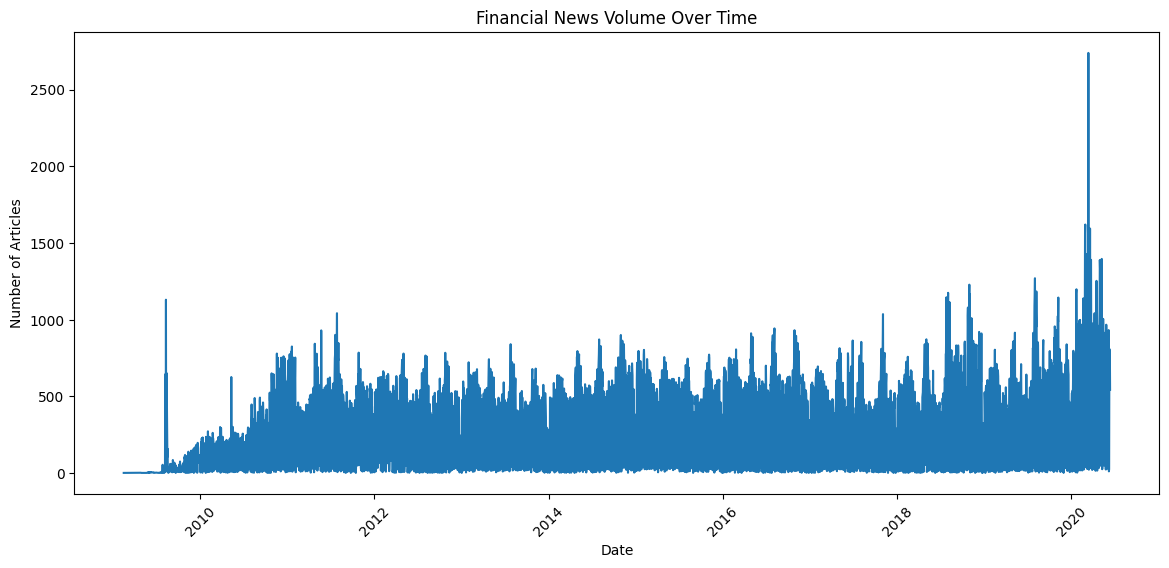

,date_only,article_count
3863,2020-03-12,2739
3850,2020-02-28,1620
3870,2020-03-19,1594
3849,2020-02-27,1567
3857,2020-03-06,1428
3919,2020-05-07,1396
3874,2020-03-23,1390
3911,2020-04-29,1389
3862,2020-03-11,1384
3912,2020-04-30,1327


In [ ]:
df["date_only"] = df["date"].dt.date
# dd
daily_news = df.groupby("date_only").size().reset_index(name="article_count")
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(daily_news["date_only"], daily_news["article_count"])

plt.title("Financial News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)

plt.show()
top_spikes = daily_news.sort_values(
    by="article_count",
    ascending=False
).head(10)

top_spikes

In [13]:
import re
df["headline_clean"] = (
    df["headline"]
    .str.lower()
    .str.strip()
)
df["headline_clean"] = df["headline_clean"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x)
)
df["headline_clean"] = df["headline_clean"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x)
)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(df["headline_clean"])
word_counts = X.sum(axis=0)
import pandas as pd

word_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_counts.A1
})
word_freq = word_freq.sort_values(
    by="count",
    ascending=False
)

word_freq.head(20)
# sample_df = df.sample(50000, random_state=42)
# vectorizer = CountVectorizer(
#     stop_words="english"
# )

# X = vectorizer.fit_transform(sample_df["headline_clean"])

,word,count
211493,vs,162061
198483,stocks,161868
128743,est,140578
128172,eps,128910
193167,shares,114182
186167,reports,108705
208402,update,91680
157011,market,90879
125308,earnings,87185
189988,sales,79524


In [1]:
import sys
print(sys.executable)

c:\Users\samiy\Desktop\pricepredict\predictingpricemoveswithnewssentiment\venv\Scripts\python.exe


In [18]:
import re

df["headline_clean"] = (
    df["headline"]
    .str.lower()
    .str.strip()
)

df["headline_clean"] = df["headline_clean"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x)
)
from sklearn.feature_extraction.text import CountVectorizer
bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    min_df=10,
    max_features=10000
)
X_bigram = bigram_vectorizer.fit_transform(
    df["headline_clean"]
)
bigram_counts = X_bigram.sum(axis=0)

bigram_freq = pd.DataFrame({
    "phrase": bigram_vectorizer.get_feature_names_out(),
    "count": bigram_counts.A1
})
bigram_freq = bigram_freq.sort_values(
    by="count",
    ascending=False
)

bigram_freq.head(30)

,phrase,count
6899,price target,47266
8585,stocks moving,40072
5638,market update,33089
3217,earnings scheduled,32055
4910,initiates coverage,28980
7318,raises pt,27206
2509,companies trading,23170
9148,trading higher,22154
1115,adj eps,21690
6860,premarket session,21670


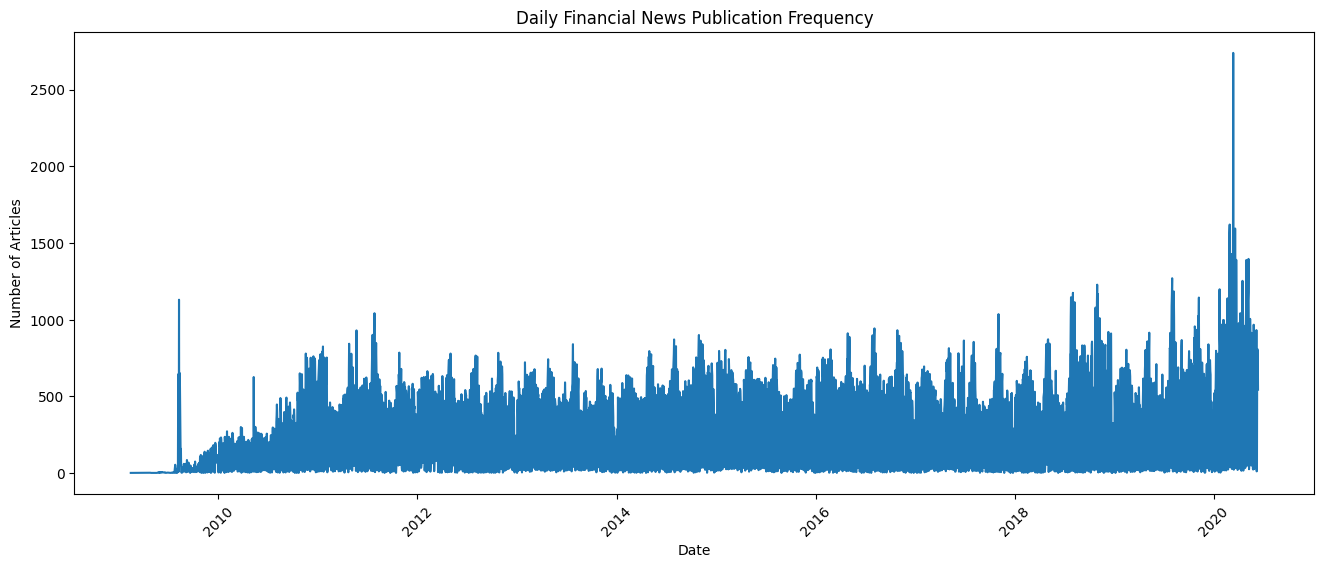

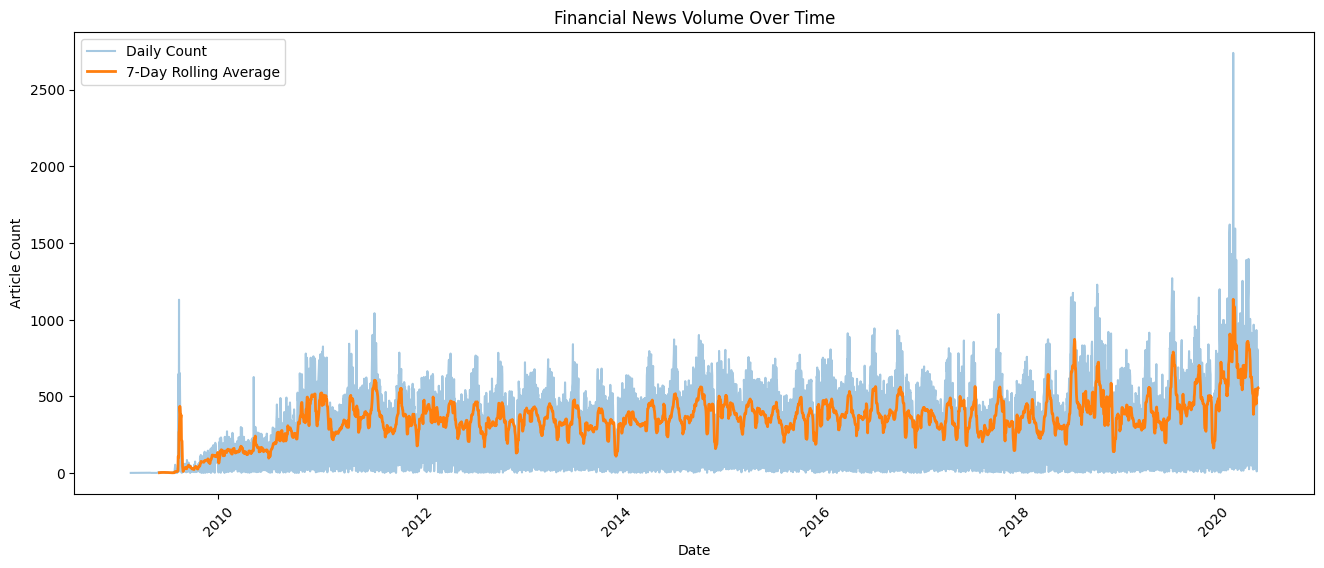

In [25]:
df["date_only"] = df["date"].dt.date
daily_publications = (
    df.groupby("date_only")
    .size()
    .reset_index(name="article_count")
)
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    daily_publications["date_only"],
    daily_publications["article_count"]
)

plt.title("Daily Financial News Publication Frequency")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()
daily_publications["rolling_avg"] = (
    daily_publications["article_count"]
    .rolling(window=7)
    .mean()
)
plt.figure(figsize=(16,6))

plt.plot(
    daily_publications["date_only"],
    daily_publications["article_count"],
    alpha=0.4,
    label="Daily Count"
)

plt.plot(
    daily_publications["date_only"],
    daily_publications["rolling_avg"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("Financial News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Article Count")

plt.legend()

plt.xticks(rotation=45)

plt.show()


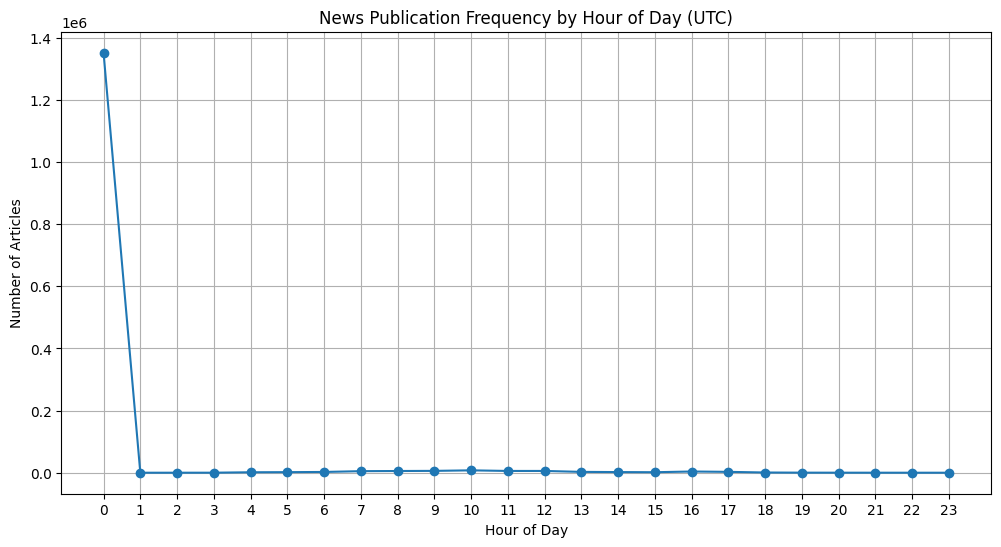

In [33]:
df["hour"] = df["date"].dt.hour
hourly_news = df.groupby("hour").size().reset_index(name="article_count")
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    hourly_news["hour"],
    hourly_news["article_count"],
    marker="o"
)

plt.title("News Publication Frequency by Hour of Day (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.xticks(range(0,24))

plt.grid(True)

plt.show()

There is high news activity between 0 to 1 hour

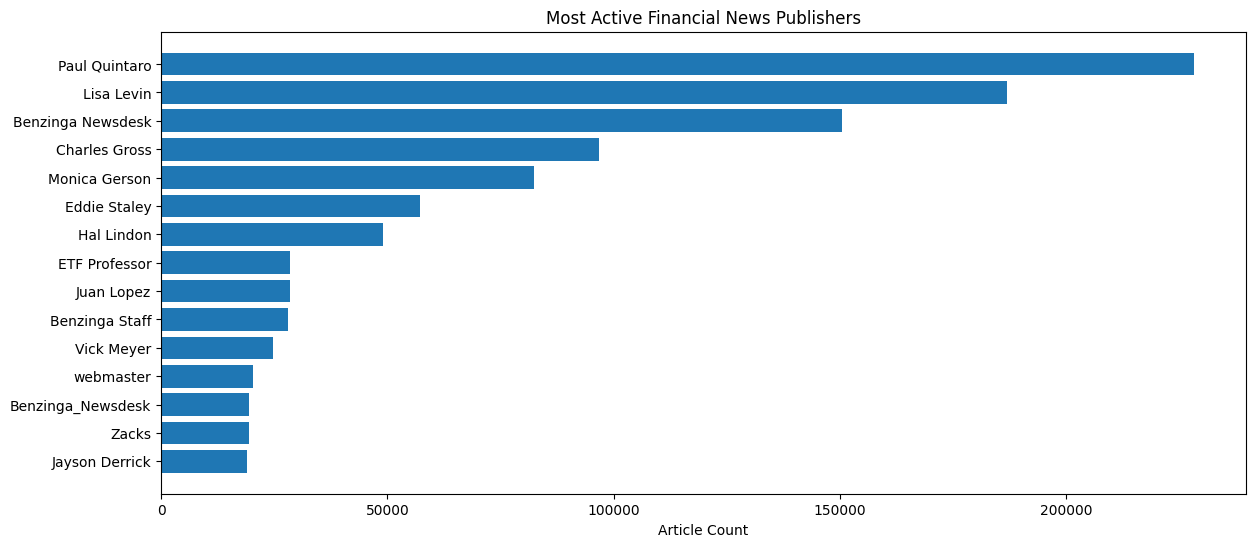

In [36]:
publisher_counts = (
    df["publisher"]
    .value_counts()
    .reset_index()
)
publisher_counts.columns = ["publisher", "article_count"]

publisher_counts.head(20)
import matplotlib.pyplot as plt

top_publishers = publisher_counts.head(15)

plt.figure(figsize=(14,6))

plt.barh(
    top_publishers["publisher"],
    top_publishers["article_count"]
)

plt.title("Most Active Financial News Publishers")
plt.xlabel("Article Count")

plt.gca().invert_yaxis()

plt.show()

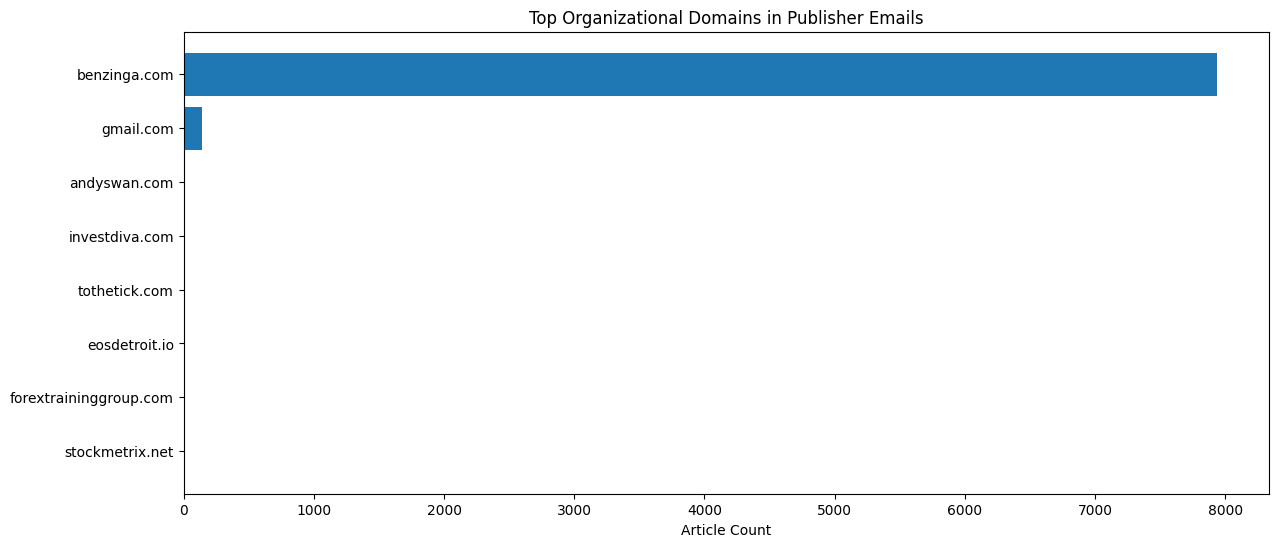

In [41]:
email_publishers = df[
    df["publisher"].str.contains("@", na=False)
]

email_publishers.head()
email_publishers["domain"] = (
    email_publishers["publisher"]
    .str.extract(r'@([\w\.-]+)')
)
domain_counts = (
    email_publishers["domain"]
    .value_counts()
    .reset_index()
)

domain_counts.columns = ["domain", "article_count"]

domain_counts.head(20)
import matplotlib.pyplot as plt

top_domains = domain_counts.head(15)

plt.figure(figsize=(14,6))

plt.barh(
    top_domains["domain"],
    top_domains["article_count"]
)

plt.title("Top Organizational Domains in Publisher Emails")
plt.xlabel("Article Count")

plt.gca().invert_yaxis()

plt.show()